# Evaluation — mono_rag vs. multi_rag

Compares the two RAG setups across three dimensions:
1. **Retrieval quality** — does the correct section appear in the top-K results?
2. **Answer quality** — LLM-as-judge content scoring (1–5)
3. **Terminology** — exact and semantic presence of the target term in the answer

> **Prerequisites**: run `mono_rag.ipynb` and `multi_rag.ipynb` first to build both ChromaDB collections.

## Section 0 — Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb
import ollama
from sentence_transformers import SentenceTransformer, CrossEncoder

from chunking   import load_documents, build_chunk_records
from retrieval  import build_bm25_index, retrieve
from generation import ask

# ── Run flags ─────────────────────────────────────────────────────────────
RUN_RETRIEVAL   = True
RUN_GENERATION  = True
RUN_TERMINOLOGY = True

# ── Model selection ───────────────────────────────────────────────────────
GENERATION_MODEL = "gemma3:4b"   # swap to e.g. mistral:7b for higher quality
JUDGE_MODEL      = "phi4-mini"   # scoring only needs a smaller model

EMBED_MODEL = "intfloat/multilingual-e5-small"
CE_MODEL    = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"

# ── RAG configurations ────────────────────────────────────────────────────
CFG_MONO = {
    "TOP_K": 2, "BM25_WEIGHT": 0.4, "SEMANTIC_POOL": 30, "RERANK_POOL": 6,
    "MODEL_NAME":      GENERATION_MODEL,
    "COLLECTION_NAME": "fdv_de_only",
    "CHROMA_DIR":      "chroma_db_de",
    "DATA_DIRS":       {"de": Path("data/de")},
}
CFG_MULTI = {
    "TOP_K": 2, "BM25_WEIGHT": 0.4, "SEMANTIC_POOL": 30, "RERANK_POOL": 6,
    "MODEL_NAME":      GENERATION_MODEL,
    "COLLECTION_NAME": "fdv_multilingual",
    "CHROMA_DIR":      "chroma_db_multilingual",
    "DATA_DIRS":       {"de": Path("data/de"),
                        "fr": Path("data/fr"),
                        "it": Path("data/it")},
}

QUESTIONS_FILE = Path("questions.csv")
ANSWERS_EXPORT = Path("results/answers_export.csv")
RESULTS_EXPORT = Path("results/evaluation_results.csv")

print(f"Generation model : {GENERATION_MODEL}")
print(f"Judge model      : {JUDGE_MODEL}")
print(f"RUN_RETRIEVAL    : {RUN_RETRIEVAL}")
print(f"RUN_GENERATION   : {RUN_GENERATION}")
print(f"RUN_TERMINOLOGY  : {RUN_TERMINOLOGY}")

c:\Users\niw\Documents\CAS_NLP_Project\Project_tRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generation model : gemma3:4b
Judge model      : phi4-mini
RUN_RETRIEVAL    : True
RUN_GENERATION   : True
RUN_TERMINOLOGY  : True


In [2]:
# Load shared models once for both setups
print("Loading embedding model...")
embedder = SentenceTransformer(EMBED_MODEL)
print("Loading cross-encoder...")
cross_encoder = CrossEncoder(CE_MODEL)

def _load_rag_system(cfg):
    docs = []
    for lang, data_dir in cfg["DATA_DIRS"].items():
        docs.extend(load_documents(data_dir, lang))
    records = build_chunk_records(docs)
    bm25    = build_bm25_index(records)
    client  = chromadb.PersistentClient(path=str(cfg["CHROMA_DIR"]))
    coll    = client.get_or_create_collection(
        name=cfg["COLLECTION_NAME"],
        metadata={"hnsw:space": "cosine"},
    )
    assert coll.count() > 0, (
        f"Collection '{cfg['COLLECTION_NAME']}' is empty — "
        "run mono_rag.ipynb / multi_rag.ipynb first."
    )
    print(f"  {cfg['COLLECTION_NAME']}: {coll.count()} chunks, {len(records)} records")
    return records, bm25, coll

print("\nLoading mono_rag...")
chunks_mono, bm25_mono, coll_mono = _load_rag_system(CFG_MONO)
print("Loading multi_rag...")
chunks_multi, bm25_multi, coll_multi = _load_rag_system(CFG_MULTI)
print("\nBoth systems ready.")

Loading embedding model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3828.03it/s]
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cross-encoder...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3980.49it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loading mono_rag...
  fdv_de_only: 1360 chunks, 1360 records
Loading multi_rag...
  fdv_multilingual: 4272 chunks, 4272 records

Both systems ready.


In [3]:
# Load questions and parse expected section
def parse_section(s):
    """'R 300.4, section 2.3.7' -> ('R 300.4', '2.3.7')"""
    s = str(s).strip()
    s = re.sub(r'\bR(\d)', r'R \1', s)          # normalise R300.x -> R 300.x
    m = re.split(r',\s*section\s+', s, flags=re.IGNORECASE)
    return (m[0].strip(), m[1].strip()) if len(m) == 2 else (s, "")

df_q = pd.read_csv(QUESTIONS_FILE)
df_q.columns = [c.strip() for c in df_q.columns]
df_q[["reg_num", "sec_id"]] = df_q["Relevant section"].apply(
    lambda s: pd.Series(parse_section(s))
)

print(f"{len(df_q)} questions loaded.")
display(df_q.head(6))

66 questions loaded.


,ID,Source Term,Query,Language,Relevant section,Target Term,reg_num,sec_id
0,1,Heizer,Was macht ein Heizer?,de,"R 300.13, section 1.1",Feuerung,R 300.13,1.1
1,2,Heizer,Quelles sont les fonctions du chauffeur?,fr,"R 300.13, section 1.1",foyer,R 300.13,1.1
2,3,Heizer,Cosa fa un fuochista?,it,"R 300.13, section 1.1",regolazione del fuoco,R 300.13,1.1
3,4,Abstossen,Welche Arten von Rangierbewegungen gibt es?,de,"R 300.4, section 1.3",abstossen,R 300.4,1.3
4,5,Abstossen,Quels genres de mouvements de manoeuvre distin...,fr,"R 300.4, section 1.3",lancer,R 300.4,1.3
5,6,Abstossen,Quali tipi di movimenti di manovra si disting...,it,"R 300.4, section 1.3",colpo,R 300.4,1.3


## Section 1 — Retrieval Evaluation

Checks whether the expected section appears in the top-K retrieved results for each setup.

In [4]:
if not RUN_RETRIEVAL:
    print("RUN_RETRIEVAL is False — skipping.")
else:
    def check_hit(results, expected_reg, expected_sec):
        """
        A hit is counted if any top-K result:
        1. Has exact metadata match (regulation_number + section_id), OR
        2. Belongs to the right regulation AND the expected section heading
           appears in the chunk text — handles cases where a short section
           was merged into an adjacent chunk and is labeled with a different id.
        """
        sec_pattern = re.compile(
            r'(?:^|\n)\t?' + re.escape(str(expected_sec)) + r'\t',
        )
        for r in results:
            if r.get("regulation_number", "").strip() != expected_reg:
                continue
            # Exact metadata match
            if str(r.get("section_id", "")).strip() == str(expected_sec).strip():
                return True
            # Section heading present in chunk text
            if sec_pattern.search(r.get("text", "")):
                return True
        return False

    retr_rows = []
    total = len(df_q)
    for i, row in df_q.iterrows():
        print(f"  [{i+1}/{total}] {row['Query'][:65]}", end="\r")
        res_mono  = retrieve(row["Query"], embedder, cross_encoder,
                             coll_mono,  bm25_mono,  chunks_mono,  CFG_MONO)
        res_multi = retrieve(row["Query"], embedder, cross_encoder,
                             coll_multi, bm25_multi, chunks_multi, CFG_MULTI)

        hit_mono  = check_hit(res_mono,  row["reg_num"], row["sec_id"])
        hit_multi = check_hit(res_multi, row["reg_num"], row["sec_id"])

        retr_rows.append({
            "ID":          row["ID"],
            "Source Term": row["Source Term"],
            "Language":    row["Language"],
            "reg_num":     row["reg_num"],
            "hit_mono":    hit_mono,
            "hit_multi":   hit_multi,
            "rerank_mono":  res_mono[0]["rerank_score"]  if res_mono  else None,
            "rerank_multi": res_multi[0]["rerank_score"] if res_multi else None,
        })

    df_retr = pd.DataFrame(retr_rows)
    print(f"\nRetrieval complete for {len(df_retr)} questions.")

  [66/66] Quando è vietata la memorizzazione dei percorsi durante le corse 
Retrieval complete for 66 questions.


Setup          Hits  Total   Hit rate
--------------------------------------
mono_rag         38     66      57.6%
multi_rag        60     66      90.9%

Hit rate by language:


,mono_rag (%),multi_rag (%)
Language,,
de,90.9,90.9
fr,31.8,90.9
it,50.0,90.9



Hit rate by regulation:


,mono_rag (%),multi_rag (%)
reg_num,,
R 300.1,0.0,0.0
R 300.2,100.0,100.0
R 300.4,60.0,100.0
R 300.5,50.0,100.0
R 300.6,66.7,100.0
R 300.7,100.0,100.0
R 300.8,100.0,100.0
R 300.9,22.2,66.7
R 300.12,66.7,100.0


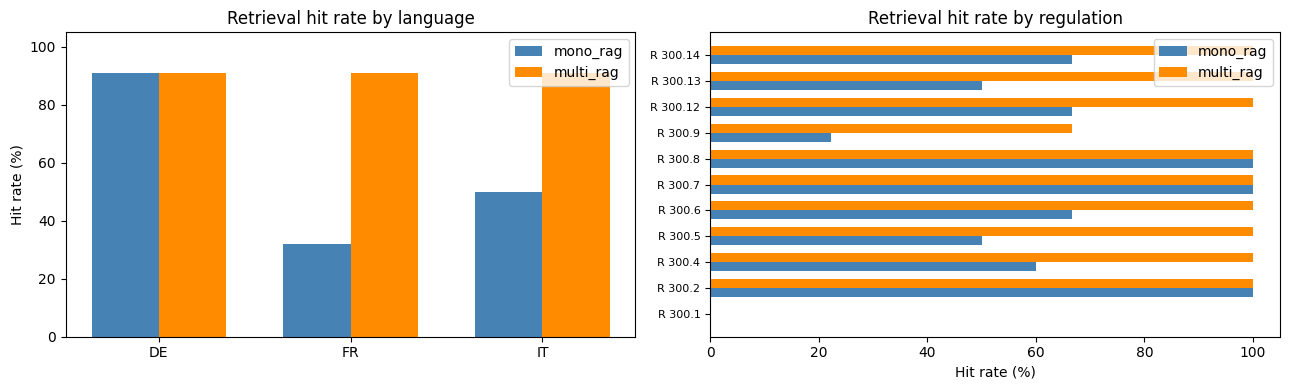


Mean top-1 rerank score — hits vs. misses:
  mono_rag      hits=5.256  misses=-0.599
  multi_rag     hits=7.463  misses=3.899


In [5]:
if not RUN_RETRIEVAL:
    print("RUN_RETRIEVAL is False — skipping.")
else:
    n = len(df_retr)

    # Overall hit rate
    print(f"{'Setup':<12} {'Hits':>6} {'Total':>6} {'Hit rate':>10}")
    print("-" * 38)
    for setup, col in [("mono_rag", "hit_mono"), ("multi_rag", "hit_multi")]:
        hits = int(df_retr[col].sum())
        print(f"{setup:<12} {hits:>6} {n:>6} {100*hits/n:>9.1f}%")

    # By language
    lang_r = df_retr.groupby("Language")[["hit_mono", "hit_multi"]].mean() * 100
    lang_r.columns = ["mono_rag (%)", "multi_rag (%)"]
    print("\nHit rate by language:"); display(lang_r.round(1))

    # By regulation
    reg_r = df_retr.groupby("reg_num")[["hit_mono", "hit_multi"]].mean() * 100
    reg_r.columns = ["mono_rag (%)", "multi_rag (%)"]
    reg_r = reg_r.sort_index(key=lambda s: s.str.extract(r'(\d+)$')[0].astype(int))
    print("\nHit rate by regulation:"); display(reg_r.round(1))

    # Charts
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    langs = lang_r.index.tolist(); x = np.arange(len(langs)); w = 0.35
    axes[0].bar(x - w/2, lang_r["mono_rag (%)"],  w, label="mono_rag",  color="steelblue")
    axes[0].bar(x + w/2, lang_r["multi_rag (%)"], w, label="multi_rag", color="darkorange")
    axes[0].set_xticks(x); axes[0].set_xticklabels([l.upper() for l in langs])
    axes[0].set_ylabel("Hit rate (%)"); axes[0].set_ylim(0, 105)
    axes[0].set_title("Retrieval hit rate by language"); axes[0].legend()

    regs = reg_r.index.tolist(); y = np.arange(len(regs))
    axes[1].barh(y - w/2, reg_r["mono_rag (%)"],  w, label="mono_rag",  color="steelblue")
    axes[1].barh(y + w/2, reg_r["multi_rag (%)"], w, label="multi_rag", color="darkorange")
    axes[1].set_yticks(y); axes[1].set_yticklabels(regs, fontsize=8)
    axes[1].set_xlabel("Hit rate (%)"); axes[1].set_xlim(0, 105)
    axes[1].set_title("Retrieval hit rate by regulation"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # Rerank scores: hits vs. misses
    print("\nMean top-1 rerank score — hits vs. misses:")
    for setup, hc, sc in [("mono_rag", "hit_mono", "rerank_mono"),
                           ("multi_rag", "hit_multi", "rerank_multi")]:
        h = df_retr.loc[df_retr[hc] == True,  sc].mean()
        m = df_retr.loc[df_retr[hc] == False, sc].mean()
        print(f"  {setup:<12}  hits={h:.3f}  misses={m:.3f}")

In [6]:
if not RUN_RETRIEVAL:
    print("RUN_RETRIEVAL is False — skipping export.")
else:
    retrieval_export = Path("results/retrieval_results.csv")
    df_retr_export = df_q[["ID", "Source Term", "Query", "Language",
                            "Relevant section", "Target Term"]].merge(
        df_retr[["ID", "hit_mono", "hit_multi", "rerank_mono", "rerank_multi"]],
        on="ID", how="left"
    )
    df_retr_export.to_csv(retrieval_export, index=False, encoding="utf-8-sig")
    print(f"Retrieval results saved to {retrieval_export}")

Retrieval results saved to results\retrieval_results.csv


In [7]:
# Deep-dive on a specific query
# Change INSPECT_ID to investigate any retrieval miss
INSPECT_ID = 25

row     = df_q[df_q["ID"] == INSPECT_ID].iloc[0]
query   = row["Query"]
exp_reg = row["reg_num"]
exp_sec = row["sec_id"]

print(f"ID {INSPECT_ID}: {query}")
print(f"Expected: {exp_reg} §{exp_sec}\n")

res_mono  = retrieve(query, embedder, cross_encoder,
                     coll_mono,  bm25_mono,  chunks_mono,  CFG_MONO)
res_multi = retrieve(query, embedder, cross_encoder,
                     coll_multi, bm25_multi, chunks_multi, CFG_MULTI)

sec_pattern = re.compile(r'(?:^|\n)\t?' + re.escape(str(exp_sec)) + r'\t')

for label, results in [("mono_rag", res_mono), ("multi_rag", res_multi)]:
    print(f"{'─'*68}")
    print(f"{label}:")
    for j, r in enumerate(results, 1):
        reg      = r.get("regulation_number", "")
        sid      = r.get("section_id", "")
        lang     = r.get("language", "")
        meta_hit = reg == exp_reg and str(sid).strip() == str(exp_sec).strip()
        text_hit = reg == exp_reg and bool(sec_pattern.search(r.get("text", "")))
        flag     = "✓ HIT (meta)" if meta_hit else "✓ HIT (text)" if text_hit else "✗ miss"
        print(f"  [{j}] {flag:14}  [{lang.upper()}] {reg} §{sid}"
              f"  rerank={r['rerank_score']:+.3f}  sem={r['sem_score']:.3f}"
              f"  bm25={r['bm25_score']:.3f}")
        print(f"       {r['text'][:120].strip()!r}")
print(f"{'─'*68}")

ID 25: Wie können dem Lokführer die Zustimmung zur Fahrt auf Strecken ohne Hauptsignale erteilt werden?
Expected: R 300.6 §1.3.4

────────────────────────────────────────────────────────────────────
mono_rag:
  [1] ✓ HIT (meta)    [DE] R 300.6 §1.3.4  rerank=+7.398  sem=0.913  bm25=1.000
       '1.3.4\tZustimmung zur Fahrt auf Strecken ohne Hauptsignale\n\n\tDie Zustimmung zur Fahrt wird dem LF wie folgt erteilt:\n–\tmi'
  [2] ✗ miss          [DE] R 300.9 §2.4  rerank=+4.809  sem=0.900  bm25=0.842
       '2.4\tZustimmung\n2.4.1\tZustimmung bei Zügen\n\t\n\tDie Zustimmung wird wie folgt erteilt:\n–\tmit Fahrtstellung des Hauptsignals'
────────────────────────────────────────────────────────────────────
multi_rag:
  [1] ✓ HIT (meta)    [DE] R 300.6 §1.3.4  rerank=+7.398  sem=0.913  bm25=1.000
       '1.3.4\tZustimmung zur Fahrt auf Strecken ohne Hauptsignale\n\n\tDie Zustimmung zur Fahrt wird dem LF wie folgt erteilt:\n–\tmi'
  [2] ✗ miss          [DE] R 300.9 §2.4  rerank=+4.809  sem=0.

## Section 2 — Answer Generation & Export

Generates answers for all 66 questions using both setups.  
Saves to `answers_export.csv` immediately — colleagues can review answers independently of the scoring steps, and Sections 3 & 4 can reload from file without re-running generation.

In [8]:
if not RUN_GENERATION:
    print("RUN_GENERATION is False — skipping generation.")
    print(f"Sections 3 & 4 will reload from {ANSWERS_EXPORT} if it exists.")
else:
    answer_rows = []
    total = len(df_q)
    for i, row in df_q.iterrows():
        print(f"  [{i+1}/{total}] {row['Query'][:70]}", end="\r")
        ans_mono,  _ = ask(row["Query"], embedder, cross_encoder,
                           coll_mono,  bm25_mono,  chunks_mono,  CFG_MONO)
        ans_multi, _ = ask(row["Query"], embedder, cross_encoder,
                           coll_multi, bm25_multi, chunks_multi, CFG_MULTI)
        answer_rows.append({
            "ID":               row["ID"],
            "Source Term":      row["Source Term"],
            "Query":            row["Query"],
            "Language":         row["Language"],
            "Relevant section": row["Relevant section"],
            "Target Term":      row["Target Term"],
            "answer_mono":      ans_mono,
            "answer_multi":     ans_multi,
        })

    df_answers = pd.DataFrame(answer_rows)
    df_answers.to_csv(ANSWERS_EXPORT, index=False, encoding="utf-8-sig")
    print(f"\nGeneration complete. {len(df_answers)} answers saved to {ANSWERS_EXPORT}")
    display(df_answers[["ID", "Language", "Query", "answer_mono", "answer_multi"]].head(3))

  [66/66] Quando è vietata la memorizzazione dei percorsi durante le corse di ma
Generation complete. 66 answers saved to results\answers_export.csv


,ID,Language,Query,answer_mono,answer_multi
0,1,de,Was macht ein Heizer?,Laut Abschnitt 1.1 der Fahrdienstvorschriften ...,Laut Abschnitt 1.1 der Fahrdienstvorschriften ...
1,2,fr,Quelles sont les fonctions du chauffeur?,Les extraits fournis ne contiennent pas d'info...,"D'après l'extrait 1, la personne désignée comm..."
2,3,it,Cosa fa un fuochista?,Basierend auf den bereitgestellten Auszügen üb...,"According to Excerpt 1, Section 1.1, the fuoch..."


## Section 3 — Answer Quality (Content)

LLM-as-judge (`JUDGE_MODEL`) rates each answer 1–5 given the question and the reference section text from the source documents.

Using 66 answers already in memory.
  Judging [66/66]...
Judging complete.


,ID,Language,Query,judge_score_mono,judge_score_multi,judge_delta
0,1,de,Was macht ein Heizer?,5,5,0
1,2,fr,Quelles sont les fonctions du chauffeur?,1,4,3
2,3,it,Cosa fa un fuochista?,3,1,-2
3,4,de,Welche Arten von Rangierbewegungen gibt es?,5,5,0
4,5,fr,Quels genres de mouvements de manoeuvre distingue-t-on?,4,4,0
5,6,it,Quali tipi di movimenti di manovra si distinguono?,5,4,-1
6,7,de,Unter welchen Bedingungen sind Rangierfahrten gegen eingestellte Zugfahrstrassen erlaubt?,4,4,0
7,8,fr,Dans quelles conditions les courses de manœuvre en direction d'itinéraires de train établis sont-elles autorisées?,2,4,2
8,9,it,In quali condizioni sono ammessi i movimenti di manovra verso percorsi treni disposti?,2,2,0
9,10,de,Welche Fahrzeuge dürfen nicht in Züge eingereiht werden?,2,2,0



Mean judge score by language:


,mono_rag,multi_rag
Language,,
de,4.05,4.32
fr,2.64,4.09
it,2.95,3.77



Overall — mono_rag: 3.21  multi_rag: 4.06  delta: +0.85


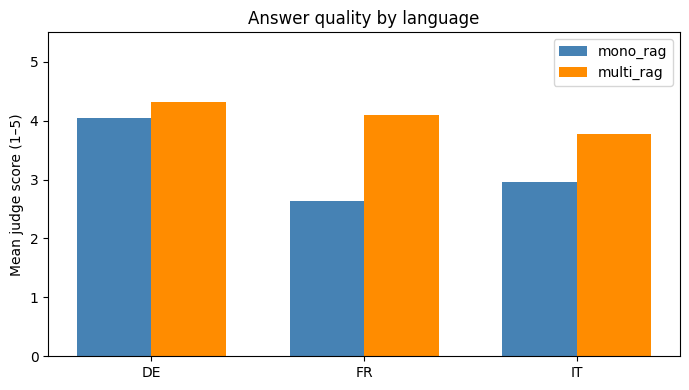

In [9]:
if not RUN_GENERATION:
    print("RUN_GENERATION is False — skipping content scoring.")
else:
    # Reload answers from file if not already in memory
    try:
        df_answers
        print(f"Using {len(df_answers)} answers already in memory.")
    except NameError:
        if ANSWERS_EXPORT.exists():
            df_answers = pd.read_csv(ANSWERS_EXPORT)
            print(f"Loaded {len(df_answers)} answers from {ANSWERS_EXPORT}")
        else:
            raise FileNotFoundError(
                f"{ANSWERS_EXPORT} not found. Run Section 2 with RUN_GENERATION=True first."
            )

    def _get_ref_text(chunk_records, reg_num, sec_id, max_chars=600):
        for r in chunk_records:
            if (r["regulation_number"] == reg_num and
                    str(r.get("section_id", "")) == str(sec_id)):
                return r["text"][:max_chars]
        for r in chunk_records:  # fallback: any chunk from that regulation
            if r["regulation_number"] == reg_num:
                return r["text"][:max_chars]
        return ""

    JUDGE_SYSTEM = (
        "You are an evaluation assistant. Rate how well the RAG answer responds to the "
        "question based on the reference passage from the source document.\n"
        "Scale: 5 = fully correct and complete, 4 = mostly correct with minor gaps, "
        "3 = partially correct, 2 = mostly incorrect, 1 = completely wrong.\n"
        "Reply with only: SCORE: <1-5>\nREASON: <one sentence>"
    )

    def _llm_judge(query, ref_text, answer):
        user_msg = (
            f"Question: {query}\n\n"
            f"Reference passage:\n{ref_text}\n\n"
            f"RAG answer:\n{answer}"
        )
        try:
            resp = ollama.chat(
                model=JUDGE_MODEL,
                messages=[
                    {"role": "system", "content": JUDGE_SYSTEM},
                    {"role": "user",   "content": user_msg},
                ],
                options={"temperature": 0.0},
            )
            raw   = resp.message.content.strip()
            score, reason = None, ""
            for line in raw.splitlines():
                if line.upper().startswith("SCORE:"):
                    try: score = int(line.split(":", 1)[1].strip()[0])
                    except: pass
                elif line.upper().startswith("REASON:"):
                    reason = line.split(":", 1)[1].strip()
            return score, reason
        except Exception as e:
            return None, str(e)

    df_j = df_answers.copy()
    df_j[["reg_num", "sec_id"]] = df_j["Relevant section"].apply(
        lambda s: pd.Series(parse_section(s))
    )

    s_mono, r_mono, s_multi, r_multi = [], [], [], []
    total = len(df_j)
    for i, row in df_j.iterrows():
        print(f"  Judging [{i+1}/{total}]...", end="\r")
        ref = _get_ref_text(chunks_mono, row["reg_num"], row["sec_id"])
        sm, rm   = _llm_judge(row["Query"], ref, row["answer_mono"])
        sml, rml = _llm_judge(row["Query"], ref, row["answer_multi"])
        s_mono.append(sm);  r_mono.append(rm)
        s_multi.append(sml); r_multi.append(rml)

    df_j["judge_score_mono"]   = s_mono
    df_j["judge_reason_mono"]  = r_mono
    df_j["judge_score_multi"]  = s_multi
    df_j["judge_reason_multi"] = r_multi
    df_j["judge_delta"] = (
        pd.to_numeric(df_j["judge_score_multi"], errors="coerce") -
        pd.to_numeric(df_j["judge_score_mono"],  errors="coerce")
    )
    print(f"\nJudging complete.")

    # Per-question table
    display(df_j[["ID", "Language", "Query",
                  "judge_score_mono", "judge_score_multi", "judge_delta"]]
            .style.background_gradient(subset=["judge_delta"],
                                       cmap="RdYlGn", vmin=-4, vmax=4))

    # By language
    lang_j = df_j.groupby("Language")[["judge_score_mono", "judge_score_multi"]].mean()
    lang_j.columns = ["mono_rag", "multi_rag"]
    print("\nMean judge score by language:"); display(lang_j.round(2))

    print(f"\nOverall — mono_rag: {df_j['judge_score_mono'].mean():.2f}  "
          f"multi_rag: {df_j['judge_score_multi'].mean():.2f}  "
          f"delta: {df_j['judge_delta'].mean():+.2f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    langs = lang_j.index.tolist(); x = np.arange(len(langs)); w = 0.35
    ax.bar(x - w/2, lang_j["mono_rag"],  w, label="mono_rag",  color="steelblue")
    ax.bar(x + w/2, lang_j["multi_rag"], w, label="multi_rag", color="darkorange")
    ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
    ax.set_ylabel("Mean judge score (1–5)"); ax.set_ylim(0, 5.5)
    ax.set_title("Answer quality by language"); ax.legend()
    plt.tight_layout(); plt.show()

## Section 4 — Terminology Evaluation

Two checks per answer:
1. **Exact match** — case-insensitive substring search for `Target Term`
2. **Semantic match** — `JUDGE_MODEL` decides whether the concept is expressed (catches synonyms and translations)

  Terminology [66/66]...
Terminology checks complete.

                         mono_rag  multi_rag
--------------------------------------------
Exact match                 27.3%      63.6%
Semantic match              31.8%      65.2%

By language:


,exact_mono(%),exact_multi(%),sem_mono(%),sem_multi(%)
Language,,,,
de,68.2,63.6,54.5,54.5
fr,9.1,77.3,22.7,68.2
it,4.5,50.0,18.2,72.7


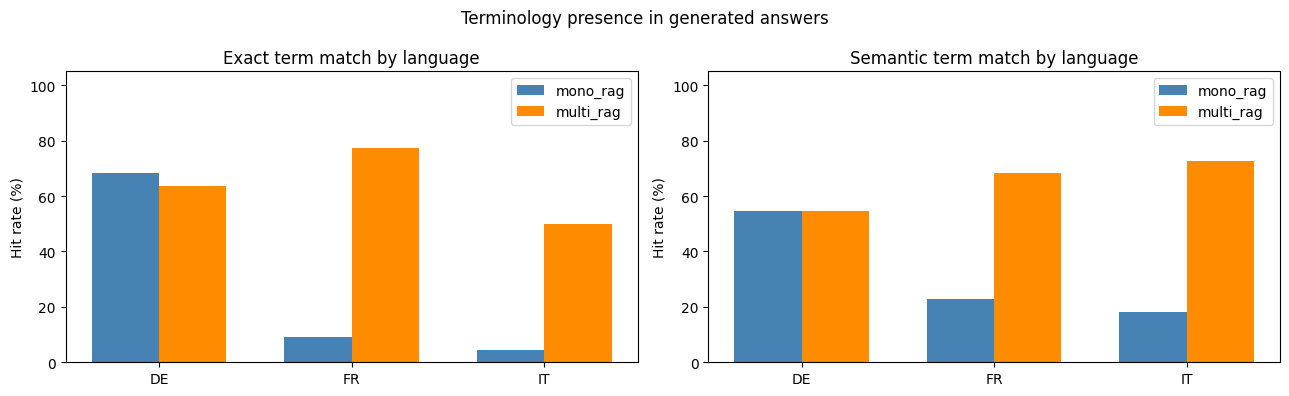

In [10]:
if not RUN_TERMINOLOGY:
    print("RUN_TERMINOLOGY is False — skipping.")
else:
    # Reload answers from file if not already in memory
    try:
        df_answers
    except NameError:
        if ANSWERS_EXPORT.exists():
            df_answers = pd.read_csv(ANSWERS_EXPORT)
            print(f"Loaded {len(df_answers)} answers from {ANSWERS_EXPORT}")
        else:
            raise FileNotFoundError(
                f"{ANSWERS_EXPORT} not found. Run Section 2 with RUN_GENERATION=True first."
            )

    def _exact_match(answer, term):
        return str(term).lower() in str(answer).lower()

    def _semantic_match(answer, term):
        user_msg = (
            f"Answer: {answer}\n\n"
            f"Does this answer express the concept of '{term}'? "
            f"Reply with only YES or NO."
        )
        try:
            resp = ollama.chat(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": user_msg}],
                options={"temperature": 0.0},
            )
            return resp.message.content.strip().upper().startswith("YES")
        except:
            return None

    df_t = df_answers.copy()
    em, em2, sm, sm2 = [], [], [], []
    total = len(df_t)

    for i, row in df_t.iterrows():
        print(f"  Terminology [{i+1}/{total}]...", end="\r")
        term = row["Target Term"]
        em.append(_exact_match(row["answer_mono"],  term))
        em2.append(_exact_match(row["answer_multi"], term))
        sm.append(_semantic_match(row["answer_mono"],  term))
        sm2.append(_semantic_match(row["answer_multi"], term))

    df_t["exact_mono"]  = em
    df_t["exact_multi"] = em2
    df_t["sem_mono"]    = sm
    df_t["sem_multi"]   = sm2
    print(f"\nTerminology checks complete.")

    # Overall rates
    n = len(df_t)
    print(f"\n{'':22} {'mono_rag':>10} {'multi_rag':>10}")
    print("-" * 44)
    print(f"{'Exact match':22} "
          f"{100*pd.Series(em).mean():>9.1f}% "
          f"{100*pd.Series(em2).mean():>9.1f}%")
    print(f"{'Semantic match':22} "
          f"{100*pd.to_numeric(pd.Series(sm), errors='coerce').mean():>9.1f}% "
          f"{100*pd.to_numeric(pd.Series(sm2), errors='coerce').mean():>9.1f}%")

    # By language
    lang_t = df_t.groupby("Language")[["exact_mono", "exact_multi",
                                        "sem_mono",   "sem_multi"]].mean() * 100
    lang_t.columns = ["exact_mono(%)", "exact_multi(%)",
                      "sem_mono(%)",   "sem_multi(%)"]
    print("\nBy language:"); display(lang_t.round(1))

    # Charts
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    langs = lang_t.index.tolist(); x = np.arange(len(langs)); w = 0.35
    for ax, mc, mlc, title in [
        (axes[0], "exact_mono(%)",  "exact_multi(%)",  "Exact term match by language"),
        (axes[1], "sem_mono(%)",    "sem_multi(%)",    "Semantic term match by language"),
    ]:
        ax.bar(x - w/2, lang_t[mc],  w, label="mono_rag",  color="steelblue")
        ax.bar(x + w/2, lang_t[mlc], w, label="multi_rag", color="darkorange")
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
        ax.set_ylabel("Hit rate (%)"); ax.set_ylim(0, 105)
        ax.set_title(title); ax.legend()
    plt.suptitle("Terminology presence in generated answers")
    plt.tight_layout(); plt.show()

## Section 5 — Summary & Export

In [11]:
# Merge all results computed in this session
try:
    base = df_answers.copy()
except NameError:
    base = df_q[["ID", "Source Term", "Query", "Language",
                 "Relevant section", "Target Term"]].copy()

if RUN_RETRIEVAL and "df_retr" in dir():
    base = base.merge(
        df_retr[["ID", "hit_mono", "hit_multi", "rerank_mono", "rerank_multi"]],
        on="ID", how="left"
    )

if RUN_GENERATION and "df_j" in dir():
    base = base.merge(
        df_j[["ID", "judge_score_mono", "judge_reason_mono",
              "judge_score_multi", "judge_reason_multi", "judge_delta"]],
        on="ID", how="left"
    )

if RUN_TERMINOLOGY and "df_t" in dir():
    base = base.merge(
        df_t[["ID", "exact_mono", "exact_multi", "sem_mono", "sem_multi"]],
        on="ID", how="left"
    )

base.to_csv(RESULTS_EXPORT, index=False, encoding="utf-8-sig")
print(f"Full results saved to {RESULTS_EXPORT}")
display(base.head(3))

# Summary table
rows = []
if RUN_RETRIEVAL and "df_retr" in dir():
    rows.append({"Metric": "Retrieval hit rate (%)",
                 "mono_rag": f"{100*df_retr['hit_mono'].mean():.1f}",
                 "multi_rag": f"{100*df_retr['hit_multi'].mean():.1f}"})

if RUN_GENERATION and "df_j" in dir():
    rows.append({"Metric": "Mean judge score (1–5)",
                 "mono_rag": f"{df_j['judge_score_mono'].mean():.2f}",
                 "multi_rag": f"{df_j['judge_score_multi'].mean():.2f}"})

if RUN_TERMINOLOGY and "df_t" in dir():
    rows.append({"Metric": "Exact term match (%)",
                 "mono_rag": f"{100*df_t['exact_mono'].mean():.1f}",
                 "multi_rag": f"{100*df_t['exact_multi'].mean():.1f}"})
    rows.append({"Metric": "Semantic term match (%)",
                 "mono_rag": f"{100*pd.to_numeric(df_t['sem_mono'], errors='coerce').mean():.1f}",
                 "multi_rag": f"{100*pd.to_numeric(df_t['sem_multi'], errors='coerce').mean():.1f}"})

print("\nSummary:")
display(pd.DataFrame(rows).set_index("Metric"))

Full results saved to results\evaluation_results.csv


,ID,Source Term,Query,Language,Relevant section,Target Term,answer_mono,answer_multi,hit_mono,hit_multi,...,rerank_multi,judge_score_mono,judge_reason_mono,judge_score_multi,judge_reason_multi,judge_delta,exact_mono,exact_multi,sem_mono,sem_multi
0,1,Heizer,Was macht ein Heizer?,de,"R 300.13, section 1.1",Feuerung,Laut Abschnitt 1.1 der Fahrdienstvorschriften ...,Laut Abschnitt 1.1 der Fahrdienstvorschriften ...,True,True,...,1.760924,5,The RAG answer correctly and completely explai...,5,The RAG answer correctly and completely explai...,0,True,True,True,True
1,2,Heizer,Quelles sont les fonctions du chauffeur?,fr,"R 300.13, section 1.1",foyer,Les extraits fournis ne contiennent pas d'info...,"D'après l'extrait 1, la personne désignée comm...",False,True,...,1.611021,1,The RAG answer incorrectly states that the pro...,4,The answer correctly identifies the functions ...,3,False,True,False,False
2,3,Heizer,Cosa fa un fuochista?,it,"R 300.13, section 1.1",regolazione del fuoco,Basierend auf den bereitgestellten Auszügen üb...,"According to Excerpt 1, Section 1.1, the fuoch...",True,True,...,2.042379,3,The answer partially addresses the role of a H...,1,The reference passage provided does not contai...,-2,False,False,False,True



Summary:


,mono_rag,multi_rag
Metric,,
Retrieval hit rate (%),57.6,90.9
Mean judge score (1–5),3.21,4.06
Exact term match (%),27.3,63.6
Semantic term match (%),31.8,65.2
